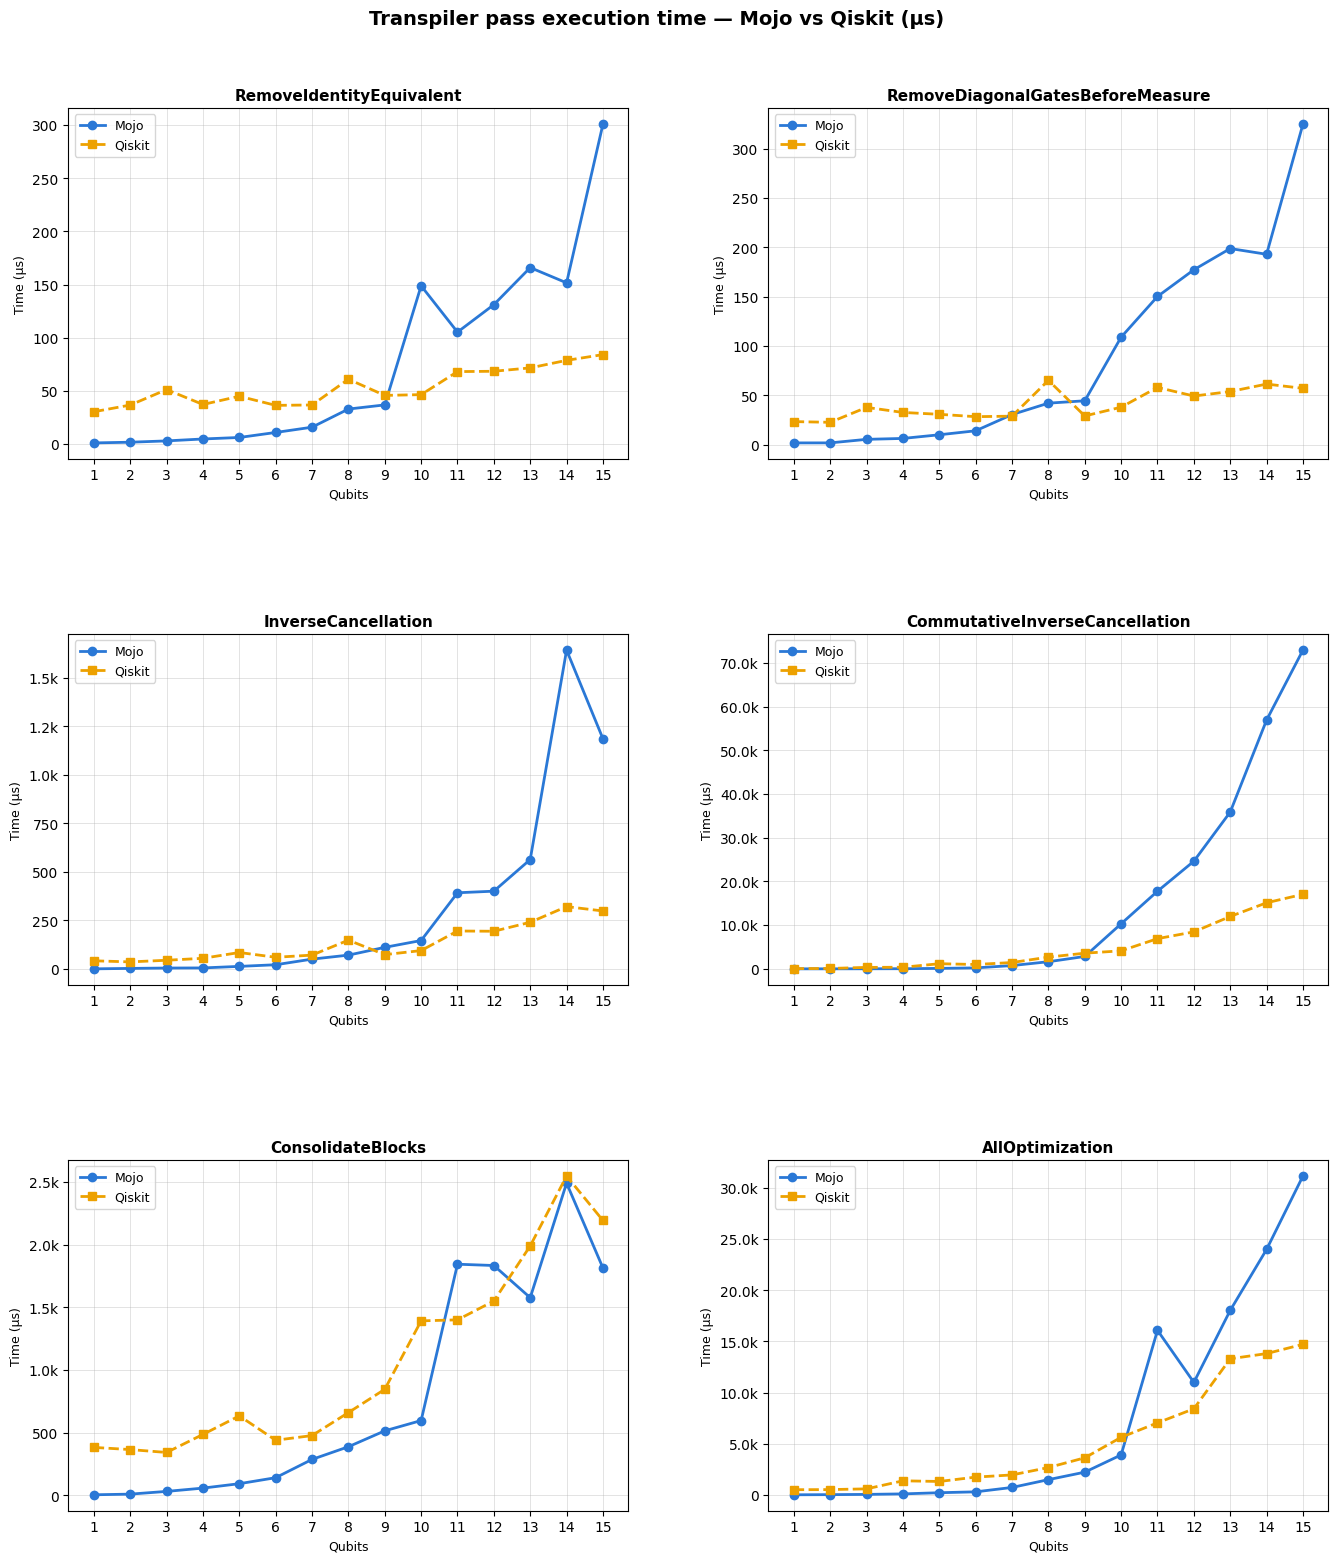

In [1]:
import argparse
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

PASSES = [
    "RemoveIdentityEquivalent",
    "RemoveDiagonalGatesBeforeMeasure",
    "InverseCancellation",
    "CommutativeInverseCancellation",
    "ConsolidateBlocks",
    "AllOptimization",
]
 
UNIT_DIVISORS = {"ns": 1, "us": 1e3, "ms": 1e6, "s": 1e9}
UNIT_LABELS   = {"ns": "ns", "us": "µs", "ms": "ms", "s": "s"}

def parse_log(path: str) -> dict[int, dict[str, int]]:
    result: dict[int, dict[str, int]] = {}
    current_q: int | None = None
    with open(path) as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue
            if line.startswith("Qubits"):
                current_q = int(line.split()[1])
                result[current_q] = {}
            else:
                parts = line.split()
                if len(parts) == 2 and current_q is not None:
                    result[current_q][parts[0]] = int(parts[1])
    return result

def convert(value_ns: float, unit: str) -> float:
    return value_ns / UNIT_DIVISORS[unit]

def plot(mojo_path: str, qiskit_path: str, unit: str, out: str | None):
    mojo_data   = parse_log(mojo_path)
    qiskit_data = parse_log(qiskit_path)
    qubits = sorted(set(mojo_data) & set(qiskit_data))
    n_passes = len(PASSES)
    ncols    = 2
    nrows    = (n_passes + 1) // ncols
    ul       = UNIT_LABELS[unit]
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(14, 5.5 * nrows))
    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.07,
        top=0.92,
        hspace=0.50,
        wspace=0.25,
    )
    axes = axes.flatten()
    for idx, pass_name in enumerate(PASSES):
        ax = axes[idx]
        mojo_times   = [convert(mojo_data.get(q, {}).get(pass_name, 0),   unit) for q in qubits]
        qiskit_times = [convert(qiskit_data.get(q, {}).get(pass_name, 0), unit) for q in qubits]
        has_mojo   = any(v > 0 for v in mojo_times)
        has_qiskit = any(v > 0 for v in qiskit_times)
        if has_mojo:
            ax.plot(qubits, mojo_times,   marker="o", linewidth=2,
                    label="Mojo",   color="#2a78d6")
        if has_qiskit:
            ax.plot(qubits, qiskit_times, marker="s", linewidth=2,
                    label="Qiskit", color="#eda100", linestyle="--")
        title_color = "#c0392b" if pass_name == "All4PassesNoMeasure" else "black"
        ax.set_title(pass_name, fontsize=11, fontweight="bold")
        ax.set_xlabel("Qubits", fontsize=9)
        ax.set_ylabel(f"Time ({ul})", fontsize=9)
        ax.set_xticks(qubits)
        ax.legend(fontsize=9)
        ax.grid(True, linewidth=0.5, alpha=0.5)
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(
                lambda v, _: f"{v/1000:.1f}k" if v >= 1000 else f"{v:.3g}"
            )
        )
    for i in range(len(PASSES), len(axes)):
        axes[i].set_visible(False)
    fig.suptitle(
        f"Transpiler pass execution time — Mojo vs Qiskit ({ul})",
        fontsize=14, fontweight="bold", y=0.98
    )
    if out:
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved → {out}")
    else:
        plt.show()

def main():
    # parser = argparse.ArgumentParser(
    #     description="Plot Mojo vs Qiskit transpiler pass timing."
    # )
    # parser.add_argument("--mojo",   default="results/optimization_transpiler/data/exe_timing_mojo_data.txt",
    #                     help="Path to Mojo timing log")
    # parser.add_argument("--qiskit", default="results/optimization_transpiler/data/exe_timing_qiskit_data.txt",
    #                     help="Path to Qiskit timing log")
    # parser.add_argument("--unit",   default="us", choices=["ns", "us", "ms", "s"],
    #                     help="Time unit for y-axis (default: ns)")
    # parser.add_argument("--out",    default=None,
    #                     help="Save to file (e.g. plot.png). Omit to show window.")
    # args = parser.parse_args()
    # plot(args.mojo, args.qiskit, args.unit, args.out)
    plot("/home/ptsapce/AISeQ-Lab/WaveFunctionPackage/WaveFunctionPk/results/optimization_transpiler/data/exe_timing_mojo_data.txt", 
         "/home/ptsapce/AISeQ-Lab/WaveFunctionPackage/WaveFunctionPk/results/optimization_transpiler/data/exe_timing_qiskit_data.txt", "us", None)
    
if __name__ == "__main__":
    main()